# Hybrid MESH calibration: Witt (1998) blended with Murillo & Homeyer (2019)

This notebook defines a **smoothly blended** Maximum Expected Size of Hail (MESH)
formulation that uses Witt (1998) below the analytical intercept of the two power
laws and Murillo & Homeyer (2019) above it, with a logistic weight providing a
$C^{\infty}$ handoff between them.

$$\text{MESH}(\text{SHI}) = (1-w)\cdot 2.54\,\text{SHI}^{0.5} + w\cdot 15.096\,\text{SHI}^{0.206}$$

$$w(\text{SHI}) = \frac{1}{1 + \exp\!\big(-k\,(\text{SHI} - \text{SHI}_*)\big)},\qquad k = \frac{2\ln 9}{\text{transition\_width}}$$

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from pyhail.mesh_formulas import mesh_smooth_blend


## Calibration constants and analytical intercept

Setting $2.54\,\text{SHI}^{0.5} = 15.096\,\text{SHI}^{0.206}$ gives
$\text{SHI}_* = (15.096/2.54)^{1/(0.5-0.206)} \approx 429.05$ J m$^{-1}$ s$^{-1}$,
with both calibrations crossing at MESH $\approx 52.6$ mm.

In [2]:
# Calibration constants
WITT_A, WITT_B = 2.54, 0.5            # Witt (1998)
MH19_A, MH19_B = 15.096, 0.206        # Murillo & Homeyer 75th percentile (2019)

# Analytical intercept of the two power laws (J m^-1 s^-1)
SHI_INTERCEPT = (MH19_A / WITT_A) ** (1.0 / (WITT_B - MH19_B))
MESH_INTERCEPT = WITT_A * SHI_INTERCEPT ** WITT_B

print(f"SHI*  = {SHI_INTERCEPT:8.3f}  J m^-1 s^-1")
print(f"MESH* = {MESH_INTERCEPT:8.3f}  mm")

SHI*  =  429.288  J m^-1 s^-1
MESH* =   52.627  mm


## Sanity check

At the pivot the blend should equal both calibrations exactly. With a very small
`transition_width` the blend should also approach the hard piecewise definition.

In [3]:
shi_test = np.array([50.0, 200.0, SHI_INTERCEPT, 700.0, 1500.0])

mesh_witt_only = WITT_A * shi_test ** WITT_B
mesh_mh19_only = MH19_A * shi_test ** MH19_B
mesh_hard = np.where(shi_test <= SHI_INTERCEPT, mesh_witt_only, mesh_mh19_only)
mesh_blend = mesh_smooth_blend(shi_test, transition_width=200.0)
mesh_tight = mesh_smooth_blend(shi_test, transition_width=10.0)  # ~ hard

print(f"{'SHI':>10}{'Witt':>10}{'MH19':>10}{'Hard':>10}{'blend_200':>12}{'blend_10':>10}")
for s, w_, m_, h_, b_, t_ in zip(shi_test, mesh_witt_only, mesh_mh19_only,
                                  mesh_hard, mesh_blend, mesh_tight):
    print(f"{s:>10.1f}{w_:>10.2f}{m_:>10.2f}{h_:>10.2f}{b_:>12.2f}{t_:>10.2f}")

       SHI      Witt      MH19      Hard   blend_200  blend_10
      50.0     17.96     33.79     17.96       17.96     17.96
     200.0     35.92     44.96     35.92       35.98     35.92
     429.3     52.63     52.63     52.63       52.63     52.63
     700.0     67.20     58.20     58.20       58.23     58.20
    1500.0     98.37     68.10     68.10       68.10     68.10


## Interactive exploration

Drag the slider to see how `transition_width` reshapes the blended curve relative
to the two underlying calibrations. The first execution may take a moment while
ipywidgets initialises in VS Code.

In [4]:
shi_grid = np.linspace(1.0, 1200.0, 600)
witt_curve = WITT_A * shi_grid ** WITT_B
mh19_curve = MH19_A * shi_grid ** MH19_B

@interact(transition_width=FloatSlider(
    min=1.0, max=400.0, step=1.0, value=200.0,
    description='Width', continuous_update=False))
def _plot_blend(transition_width=100.0):
    blend = mesh_smooth_blend(shi_grid, transition_width=transition_width)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(shi_grid, witt_curve, '--', color='gray',
            label=r'Witt 1998: $2.54\,\mathrm{SHI}^{0.5}$', lw=1.2)
    ax.plot(shi_grid, mh19_curve, '--', color='steelblue',
            label=r'M&H 2019: $15.096\,\mathrm{SHI}^{0.206}$', lw=1.2)
    ax.plot(shi_grid, blend, color='firebrick',
            label=f'Smooth blend (width = {transition_width:.0f})', lw=2.2)
    ax.scatter([SHI_INTERCEPT], [MESH_INTERCEPT], color='firebrick',
               zorder=5, label=f'Pivot (SHI = {SHI_INTERCEPT:.1f})')

    ax.set_xlabel(r'SHI (J m$^{-1}$ s$^{-1}$)')
    ax.set_ylabel('MESH (mm)')
    ax.set_xlim(50, 700)
    ax.set_ylim(10, 70)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
    ax.set_title('Hybrid MESH formulation: smooth blend')
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=200.0, continuous_update=False, description='Width', max=400.0, min=1.…

## Derivative of MESH with respect to SHI

The smoothing's main benefit is removing the kink in $d\text{MESH}/d\text{SHI}$
at the crossover point. Numerical differentiation makes this easy to see.


In [6]:
def plot_derivative(transition_width=200.0):
    shi = np.linspace(1.0, 1200.0, 4000)
    mesh_blend = mesh_smooth_blend(shi, transition_width=transition_width)
    mesh_hard = np.where(shi <= SHI_INTERCEPT,
                         WITT_A * shi ** WITT_B,
                         MH19_A * shi ** MH19_B)
    d_blend = np.gradient(mesh_blend, shi)
    d_hard = np.gradient(mesh_hard, shi)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(shi, d_hard, color='gray', label='Hard piecewise', lw=1.2)
    ax.plot(shi, d_blend, color='firebrick',
            label=f'Smooth blend (width = {transition_width:.0f})', lw=2.0)
    ax.axvline(SHI_INTERCEPT, color='k', ls=':', alpha=0.4)
    ax.set_xlabel(r'SHI (J m$^{-1}$ s$^{-1}$)')
    ax.set_ylabel(r'$d\mathrm{MESH}/d\mathrm{SHI}$ (mm per unit SHI)')
    ax.set_xlim(50, 700)
    ax.set_ylim(0, 0.2)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title('Derivative of MESH wrt SHI')
    plt.tight_layout()
    plt.show()

interact(plot_derivative, transition_width=FloatSlider(
    min=1.0, max=400.0, step=1.0, value=200.0,
    description='Width', continuous_update=False));

interactive(children=(FloatSlider(value=200.0, continuous_update=False, description='Width', max=400.0, min=1.…

## Case study: 10 November 2023

Apply all three MESH formulations to the sample volume scan used in
`testing_pyodim.ipynb` (`data/66_20231110_063000.pvol.h5`).  
SHI is computed once from the multi-elevation scan; the three MESH
calibrations are then derived from that common SHI field so the
comparison is exact.


In [7]:
import pyodim
import pyart
from pyhail import mesh_ppi
from pyhail.mesh_formulas import mesh_smooth_blend

filename = 'data/66_20231110_063000.pvol.h5'
radar_datasets = pyodim.read_odim(filename, lazy_load=False)

# Build inputs expected by mesh_ppi.main()
reflectivity_dataset, elevation_dataset, azimuth_dataset, range_dataset = [], [], [], []
radar_altitude = radar_datasets[0].attrs['height']
for ds in radar_datasets:
    reflectivity_dataset.append(ds['DBZH'].values)
    elevation_dataset.append(ds['elevation'].data[0])
    azimuth_dataset.append(ds['azimuth'].values)
    range_dataset.append(ds['range'].values)

sweep0_idx = int(np.argmin(elevation_dataset))

# Compute SHI once; apply all three MESH calibrations to the same SHI field
# so the comparison is exact and not affected by re-running the column integral.
_, shi_dict, _, _ = mesh_ppi.main(
    reflectivity_dataset,
    elevation_dataset,
    azimuth_dataset,
    range_dataset,
    radar_altitude,
    [4000, 5500],
    mesh_method='witt1998',
)
shi = shi_dict['data']

# Mask cells with no hail signal (SHI ≤ 0 or NaN) so they render as white
shi_safe = np.where((shi > 0) & ~np.isnan(shi), shi, 0.0)
no_signal = shi_safe <= 0

# Three MESH calibrations evaluated on the common SHI field
mesh_witt     = np.where(no_signal, np.nan, WITT_A * shi_safe ** WITT_B)
mesh_mh       = np.where(no_signal, np.nan, MH19_A * shi_safe ** MH19_B)
mesh_blend_cs = np.where(no_signal, np.nan, mesh_smooth_blend(shi_safe))

# Signed difference: blend minus MH2019 75th percentile
mesh_diff = mesh_blend_cs - mesh_mh



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



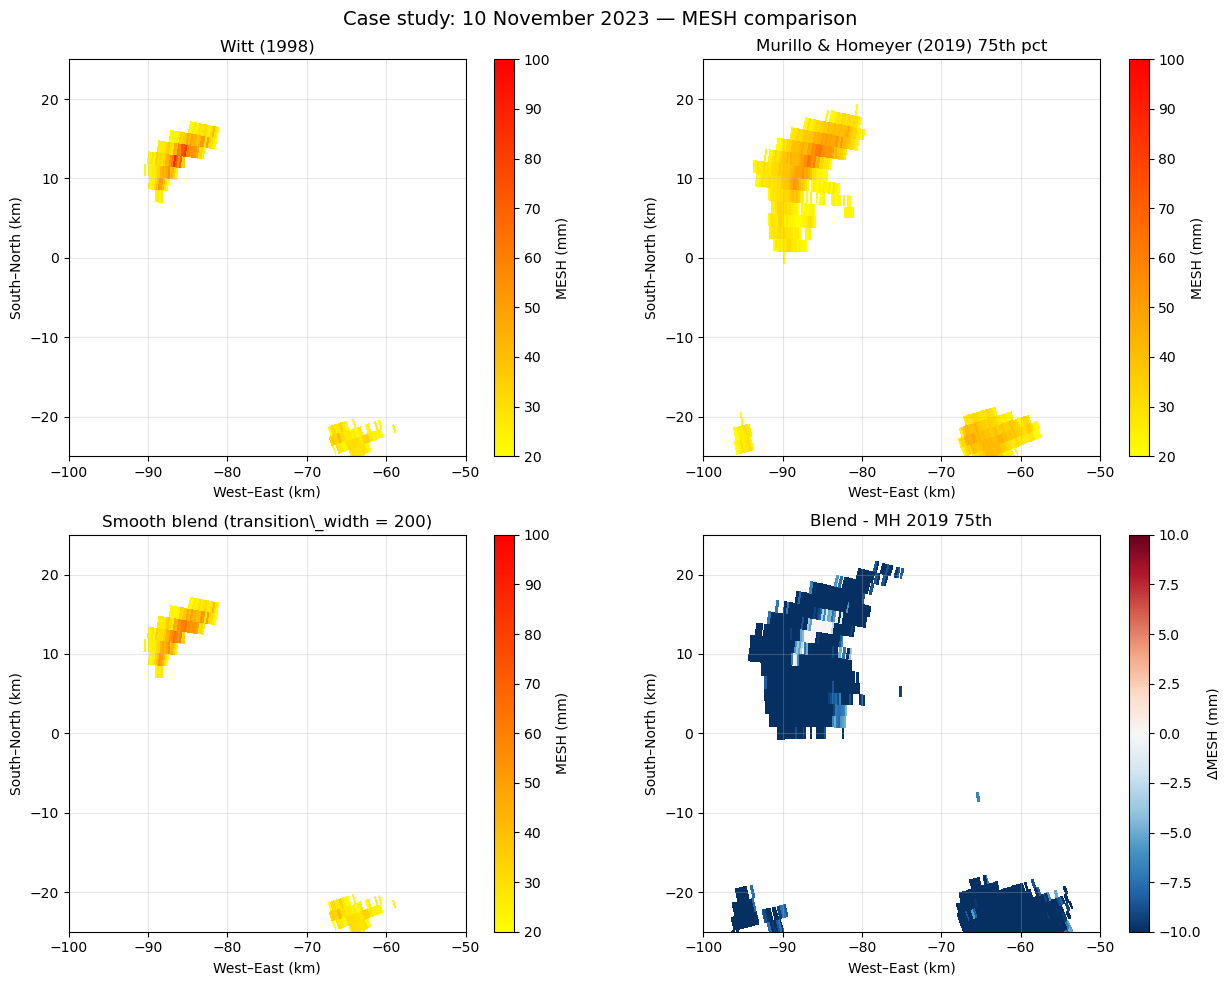

In [8]:
# Cartesian coordinates at the lowest sweep (edges for pcolormesh)
x_coords, y_coords, _ = pyart.core.antenna_vectors_to_cartesian(
    radar_datasets[sweep0_idx]['range'].data,
    radar_datasets[sweep0_idx]['azimuth'].data,
    radar_datasets[sweep0_idx]['elevation'].data,
    edges=True,
)
x_coords = x_coords / 1000
y_coords = y_coords / 1000

# Same zoom window as testing_pyodim.ipynb
x_lim = [-100, -50]
y_lim = [-25, 25]
vmin, vmax = 20, 100
cmap_mesh = plt.cm.autumn_r.copy()
cmap_mesh.set_bad('white')

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(13, 10))
axs = axs.flatten()

plot_mesh_witt = np.ma.masked_invalid(mesh_witt)
plot_mesh_witt = np.ma.masked_less(plot_mesh_witt, 20)

plot_mesh_mh = np.ma.masked_invalid(mesh_mh)
plot_mesh_mh = np.ma.masked_less(plot_mesh_mh, 20)

plot_mesh_blend_cs = np.ma.masked_invalid(mesh_blend_cs)
plot_mesh_blend_cs = np.ma.masked_less(plot_mesh_blend_cs, 20)


im = axs[0].pcolormesh(x_coords, y_coords, plot_mesh_witt, cmap=cmap_mesh, vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axs[0], label='MESH (mm)')
axs[0].set_title('Witt (1998)')

im = axs[1].pcolormesh(x_coords, y_coords, plot_mesh_mh, cmap=cmap_mesh, vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axs[1], label='MESH (mm)')
axs[1].set_title('Murillo & Homeyer (2019) 75th pct')

im = axs[2].pcolormesh(x_coords, y_coords, plot_mesh_blend_cs, cmap=cmap_mesh, vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axs[2], label='MESH (mm)')
axs[2].set_title('Smooth blend (transition\_width = 200)')

diff_max = 10
im = axs[3].pcolormesh(x_coords, y_coords, mesh_diff, cmap='RdBu_r', vmin=-diff_max, vmax=diff_max)
fig.colorbar(im, ax=axs[3], label='\u0394MESH (mm)')
axs[3].set_title('Blend - MH 2019 75th')

for ax in axs:
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel('West\u2013East (km)')
    ax.set_ylabel('South\u2013North (km)')

fig.suptitle('Case study: 10 November 2023 — MESH comparison', fontsize=14)
plt.tight_layout()
plt.show()


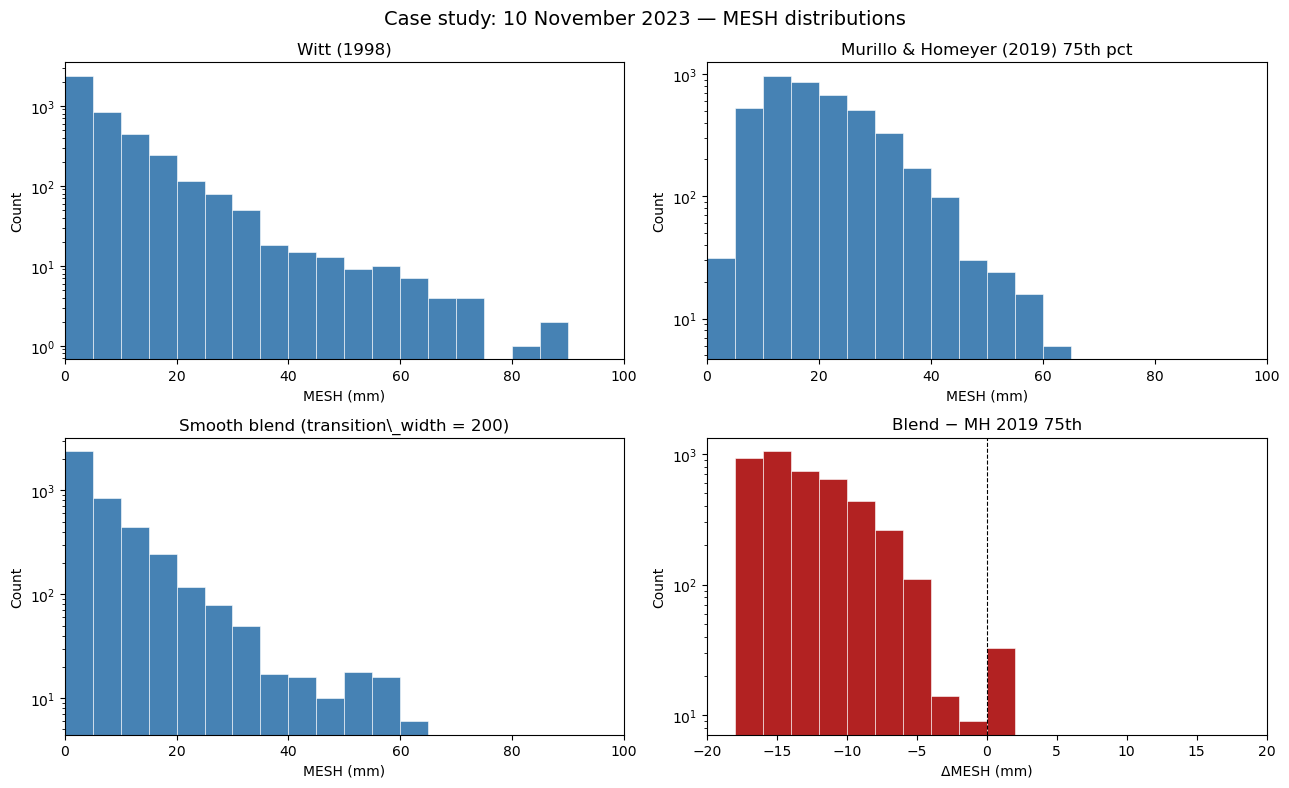

In [10]:
# Flatten and drop NaN for each field
vals_witt  = mesh_witt[~np.isnan(mesh_witt)].ravel()
vals_mh    = mesh_mh[~np.isnan(mesh_mh)].ravel()
vals_blend = mesh_blend_cs[~np.isnan(mesh_blend_cs)].ravel()
vals_diff  = mesh_diff[~np.isnan(mesh_diff)].ravel()

mesh_bins = np.arange(0, 105, 5)
diff_bins = np.arange(-20, 21, 2)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(13, 8))
axs = axs.flatten()

axs[0].hist(vals_witt, bins=mesh_bins, color='steelblue', edgecolor='white', linewidth=0.4)
axs[0].set_title('Witt (1998)')

axs[1].hist(vals_mh, bins=mesh_bins, color='steelblue', edgecolor='white', linewidth=0.4)
axs[1].set_title('Murillo & Homeyer (2019) 75th pct')

axs[2].hist(vals_blend, bins=mesh_bins, color='steelblue', edgecolor='white', linewidth=0.4)
axs[2].set_title('Smooth blend (transition\_width = 200)')

axs[3].hist(vals_diff, bins=diff_bins, color='firebrick', edgecolor='white', linewidth=0.4)
axs[3].axvline(0, color='k', lw=0.8, ls='--')
axs[3].set_title('Blend − MH 2019 75th')

for ax in axs[:3]:
    ax.set_xlabel('MESH (mm)')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 100)
    ax.set_yscale('log')

axs[3].set_xlabel('ΔMESH (mm)')
axs[3].set_ylabel('Count')
axs[3].set_xlim(-20, 20)
axs[3].set_yscale('log')

fig.suptitle('Case study: 10 November 2023 — MESH distributions', fontsize=14)
plt.tight_layout()
plt.show()
